In [1]:
# ==========================
# 1. IMPORT LIBRARY
# ==========================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

import seaborn as sns


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
# ==========================
# 2. SIAPKAN DATAFRAME (FILEPATHS + LABELS)
# ==========================

sdir = r'D:\Skripsi\model\dataset'

filepaths = []
labels = []
classlist = os.listdir(sdir)

for klass in classlist:
    classpath = os.path.join(sdir, klass)
    if os.path.isdir(classpath):
        flist = os.listdir(classpath)
        for f in flist:
            fpath = os.path.join(classpath, f)
            filepaths.append(fpath)
            labels.append(klass)

Fseries = pd.Series(filepaths, name='filepaths')
Lseries = pd.Series(labels, name='labels')
df = pd.concat([Fseries, Lseries], axis=1)

print(df.head())
print("\nJumlah data per kelas:")
print(df['labels'].value_counts())

classes = sorted(df['labels'].unique())
num_classes = len(classes)
print("\nKelas:", classes)


                                       filepaths labels
0  D:\Skripsi\model\dataset\botol\botol_1000.png  botol
1  D:\Skripsi\model\dataset\botol\botol_1001.png  botol
2  D:\Skripsi\model\dataset\botol\botol_1002.png  botol
3  D:\Skripsi\model\dataset\botol\botol_1003.png  botol
4  D:\Skripsi\model\dataset\botol\botol_1004.png  botol

Jumlah data per kelas:
labels
botol      710
kaleng     710
kardus     710
organik    710
Name: count, dtype: int64

Kelas: ['botol', 'kaleng', 'kardus', 'organik']


In [3]:
# ==========================
# 3. PARAMETER UMUM
# ==========================

height = 299
width = 299
channels = 3
img_size = (height, width)
batch_size = 32
lr = 0.001      # learning rate
dp = 0.3        # dropout

K = 5           # jumlah fold


In [4]:
# ==========================
# 4. IMAGE DATA GENERATOR
# ==========================

train_gen_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

valid_gen_aug = ImageDataGenerator(rescale=1./255)


In [5]:
# ==========================
# 5. FUNGSI MEMBANGUN MODEL
# ==========================

def create_model(lr=0.001, dp=0.3):
    base_model = InceptionV3(
        weights='imagenet',
        include_top=False,
        input_shape=(299, 299, 3)
    )

    # opsional: freeze base_model jika ingin transfer learning klasik
    # base_model.trainable = False

    model = tf.keras.Sequential([
        base_model,  # InceptionV3 base model
        tf.keras.layers.Conv2D(filters=32, padding='same', kernel_size=3,
                               activation='relu', strides=1),
        tf.keras.layers.MaxPool2D(pool_size=2, strides=2),
        tf.keras.layers.Dropout(rate=dp),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(4, activation='softmax')  # 4 kelas
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model



============== FOLD 1 / 5 ==============
  Jumlah data train : 2272
  Jumlah data valid : 568
Found 2272 validated image filenames belonging to 4 classes.
Found 568 validated image filenames belonging to 4 classes.
Epoch 1/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 531s 7s/step - accuracy: 0.6272 - loss: 0.9713 - val_accuracy: 0.2535 - val_loss: 15.6123
Epoch 2/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 497s 7s/step - accuracy: 0.8482 - loss: 0.4863 - val_accuracy: 0.3433 - val_loss: 155.7478
Epoch 3/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 499s 7s/step - accuracy: 0.8790 - loss: 0.3906 - val_accuracy: 0.2887 - val_loss: 3.2157
Epoch 4/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 495s 7s/step - accuracy: 0.8939 - loss: 0.3287 - val_accuracy: 0.5845 - val_loss: 2.3926
Epoch 5/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 491s 7s/step - accuracy: 0.9199 - loss: 0.2578 - val_accuracy: 0.8838 - val_loss: 0.3516
Epoch 6/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 491s 7s/step - accuracy: 0.9230 - loss: 0.2334 - val_accuracy: 0.7606 - val_loss: 0.8006
Epoch 7/40
71/71 ━━

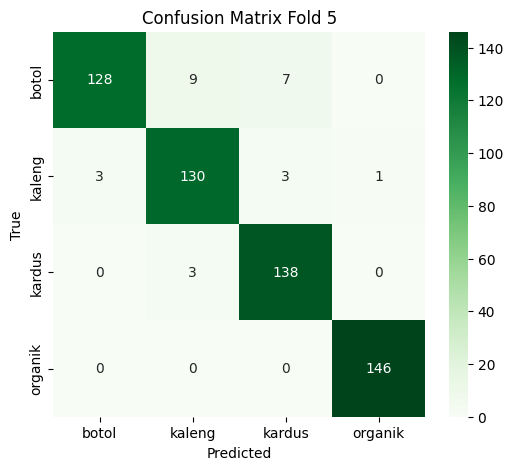


Classification Report Fold Terakhir:
              precision    recall  f1-score   support

       botol       0.98      0.89      0.93       144
      kaleng       0.92      0.95      0.93       137
      kardus       0.93      0.98      0.96       141
     organik       0.99      1.00      1.00       146

    accuracy                           0.95       568
   macro avg       0.95      0.95      0.95       568
weighted avg       0.96      0.95      0.95       568


================= HASIL AKHIR K-FOLD =================
Fold 1 - Loss: 0.3076 - Acc: 0.9032
Fold 2 - Loss: 0.2111 - Acc: 0.9366
Fold 3 - Loss: 0.4137 - Acc: 0.9067
Fold 4 - Loss: 0.3740 - Acc: 0.8979
Fold 5 - Loss: 0.1665 - Acc: 0.9542

Rata-rata Loss : 0.2946
Rata-rata Acc  : 0.9197


In [6]:
# ==========================
# 6. K-FOLD CROSS VALIDATION
# ==========================

kf = KFold(n_splits=K, shuffle=True, random_state=123)

fold_no = 1
acc_per_fold = []
loss_per_fold = []

for train_index, val_index in kf.split(df):
    print(f"\n============== FOLD {fold_no} / {K} ==============")

    # Bagi dataframe jadi train & valid berdasarkan index KFold
    train_df = df.iloc[train_index].reset_index(drop=True)
    val_df   = df.iloc[val_index].reset_index(drop=True)

    print("  Jumlah data train :", len(train_df))
    print("  Jumlah data valid :", len(val_df))

    # Generator training
    train_gen = train_gen_aug.flow_from_dataframe(
        train_df,
        x_col='filepaths',
        y_col='labels',
        target_size=img_size,
        class_mode='categorical',
        color_mode='rgb',
        batch_size=batch_size,
        shuffle=True
    )

    # Generator validasi
    val_gen = valid_gen_aug.flow_from_dataframe(
        val_df,
        x_col='filepaths',
        y_col='labels',
        target_size=img_size,
        class_mode='categorical',
        color_mode='rgb',
        batch_size=batch_size,
        shuffle=False
    )

    # Bangun model baru untuk setiap fold
    model = create_model(lr=lr, dp=dp)

    # Early stopping
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    # Latih model
    history = model.fit(
        train_gen,
        epochs=40,
        validation_data=val_gen,
        callbacks=[early_stopping],
        verbose=1
    )

    # Evaluasi di data validasi fold ini
    val_loss, val_acc = model.evaluate(val_gen, verbose=0)
    print(f"  [FOLD {fold_no}] Val Loss : {val_loss:.4f}, Val Acc : {val_acc:.4f}")

    acc_per_fold.append(val_acc)
    loss_per_fold.append(val_loss)

    # (Opsional) Confusion matrix untuk fold terakhir
    if fold_no == K:
        y_true = val_gen.classes
        y_prob = model.predict(val_gen)
        y_pred = np.argmax(y_prob, axis=1)
        class_labels = list(val_gen.class_indices.keys())

        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt="d",
                    xticklabels=class_labels,
                    yticklabels=class_labels,
                    cmap="Greens")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.title(f"Confusion Matrix Fold {fold_no}")
        plt.show()

        print("\nClassification Report Fold Terakhir:")
        print(classification_report(y_true, y_pred, target_names=class_labels))

    fold_no += 1

print("\n================= HASIL AKHIR K-FOLD =================")
for i in range(K):
    print(f"Fold {i+1} - Loss: {loss_per_fold[i]:.4f} - Acc: {acc_per_fold[i]:.4f}")

print(f"\nRata-rata Loss : {np.mean(loss_per_fold):.4f}")
print(f"Rata-rata Acc  : {np.mean(acc_per_fold):.4f}")
